In [202]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
# Load processed dataset
DATA = pd.read_csv("Combined_data_v1.csv")
DATA = DATA.drop(columns=["Unnamed: 0"])

# Creating the 'popularity' label using quantile based binning
DATA['popularity'] = pd.qcut(DATA['booking_ratio'], q=3, labels=[0, 1, 2])
DATA['price_category'] = pd.cut(DATA['price'], bins=[0, 100, 500, 1000, 5000], 
                                       labels=[0,1,2,3])

DATA = DATA[DATA['booking_ratio'] <= 0.7]
DATA = DATA.drop(columns=['price'])

print(DATA.shape)
DATA.head()

(2729, 28)


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,booking_ratio,total_amenities,popularity,price_category
0,within an hour,100,100,t,t,t,Fort Greene,Private room in guest suite,Private room,2,...,4.89,4.96,4.93,4.95,4.82,t,0.410959,51,2,1
1,within an hour,100,100,t,t,t,East Village,Private room in condo,Private room,1,...,4.77,4.79,4.79,4.73,4.69,f,0.619178,39,2,1
2,within an hour,100,100,t,t,t,Clinton Hill,Private room in condo,Private room,2,...,4.94,4.99,4.98,4.87,4.92,t,0.649315,58,2,1
3,within an hour,100,100,t,t,t,Clinton Hill,Private room in rental unit,Private room,2,...,4.46,4.77,4.76,4.75,4.60,t,0.161644,32,1,1
4,within a few hours,100,50,f,t,t,Boerum Hill,Private room in home,Private room,2,...,4.52,4.88,4.88,4.86,4.62,f,0.030137,69,0,2


In [204]:
DATA.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'minimum_nights',
       'maximum_nights', 'maximum_minimum_nights', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'booking_ratio',
       'total_amenities', 'popularity', 'price_category'],
      dtype='object')

In [205]:
#y = DATA['price_category']
#X = DATA.drop(['popularity', 'price_category'], axis=1)


#numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
#categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Column transformer imputing and encoding
#numeric_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler())
#])

#categorical_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
#    ('onehot', OneHotEncoder(handle_unknown='ignore'))
#])

#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', numeric_transformer, numeric_features),
#        ('cat', categorical_transformer, categorical_features)
#    ]
#)

# Split Data
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, stratify=y, random_state=42
#)

In [206]:

# Import necessary modules
from imblearn.over_sampling import SMOTE

# Define the target and features
y = DATA['price_category']
X = DATA.drop(['popularity', 'price_category'], axis=1)

# Split Data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Define numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Column transformer for imputing and encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)



# Apply SMOTE for oversampling the minority class
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)


# Now, X_train_resampled and y_train_resampled are the balanced datasets.

In [207]:
# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Distributions for RandomizedSearch
rf_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__bootstrap': [True, False]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)
best_rf = rf_random_search.best_estimator_

rf_preds = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_preds))
precision_rf = precision_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'
recall_rf = recall_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'
f1_rf = f1_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'

print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-Score: {f1_rf:.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Accuracy: 0.8333333333333334
Precision: 0.839
Recall: 0.501
F1-Score: 0.588


In [208]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(random_state=42))
])

# Define parameter grid for Logistic Regression
lr_param_grid = {
    'clf__solver': ['lbfgs', 'newton-cg'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__max_iter': [1000, 2000]
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

lr_grid_search.fit(X_train, y_train)
best_lr = lr_grid_search.best_estimator_

lr_preds = best_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_preds))
precision_lr = precision_score(y_test, lr_preds, average='macro')  # or 'micro' / 'weighted'
recall_lr = recall_score(y_test, lr_preds, average='macro')  # or 'micro' / 'weighted'
f1_lr = f1_score(y_test, lr_preds, average='macro')  # or 'micro' / 'weighted'

print(f"Precision: {precision_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1-Score: {f1_lr:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Accuracy: 0.8205128205128205
Precision: 0.695
Recall: 0.599
F1-Score: 0.628


In [209]:
from sklearn.ensemble import VotingClassifier

# XGBoost Pipeline

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        random_state=42, 
        eval_metric='mlogloss'
    ))
])

# Define a parameter distribution for RandomizedSearch
xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 6, 10],
    'clf__learning_rate': [0.01, 0.1, 0.3],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0],
    'clf__gamma': [0, 1, 5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)
best_xgb = xgb_random_search.best_estimator_
xgb_preds = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_preds))
precision_xgb = precision_score(y_test, xgb_preds, average='macro')  # or 'micro' / 'weighted'
recall_xgb = recall_score(y_test, xgb_preds, average='macro')  # or 'micro' / 'weighted'
f1_xgb = f1_score(y_test, xgb_preds, average='macro')  # or 'micro' / 'weighted'

print(f"Precision: {precision_xgb:.3f}")
print(f"Recall: {recall_xgb:.3f}")
print(f"F1-Score: {f1_xgb:.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Accuracy: 0.836996336996337
Precision: 0.727
Recall: 0.625
F1-Score: 0.667


In [210]:
# Best parameters of each pipeline
best_rf_clf = best_rf.named_steps['clf']
best_lr_clf = best_lr.named_steps['clf']
best_xgb_clf = best_xgb.named_steps['clf']

# Ensemble pipeline
ensemble_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('voting_clf', VotingClassifier(
        estimators=[
            ('rf', best_rf_clf),
            ('lr', best_lr_clf),
            ('xgb', best_xgb_clf)
        ],
        voting='soft'
    ))
])

ensemble_pipeline.fit(X_train, y_train)
ensemble_preds = ensemble_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, ensemble_preds))
precision = precision_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'
recall = recall_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'
f1 = f1_score(y_test, rf_preds, average='macro')  # or 'micro' / 'weighted'

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

Accuracy: 0.8424908424908425
Precision: 0.839
Recall: 0.501
F1-Score: 0.588


In [226]:
from sklearn.dummy import DummyClassifier

# Train Dummy Classifier (baseline model)
dummy_clf = DummyClassifier(strategy='uniform', random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_preds = dummy_clf.predict(X_test)

# Calculate accuracy for Dummy Classifier
acc_dummy = accuracy_score(y_test, dummy_preds)
print("Accuracy: ", acc_dummy)

precision_d = precision_score(y_test, dummy_preds, average='macro')  # or 'micro' / 'weighted'
recall_d = recall_score(y_test, dummy_preds, average='macro')  # or 'micro' / 'weighted'
f1_d = f1_score(y_test, dummy_preds, average='macro')  # or 'micro' / 'weighted'

print(f"Precision: {precision_d:.3f}")
print(f"Recall: {recall_d:.3f}")
print(f"F1-Score: {f1_d:.3f}")

Accuracy:  0.2326007326007326
Precision: 0.253
Recall: 0.190
F1-Score: 0.172


/var/folders/hd/bjwby9bd7jx83jd4dhqqp7fc0000gn/T/ipykernel_2809/57485459.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x='Model', y='Accuracy', palette='Blues_d')


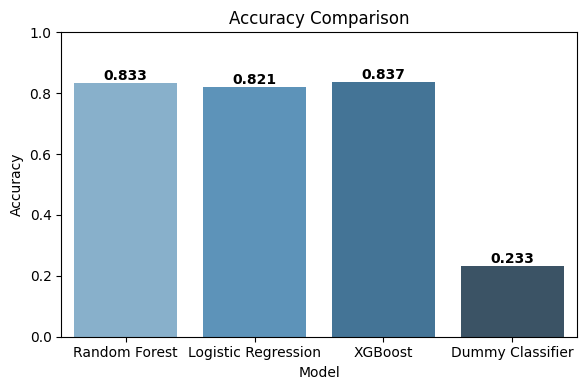

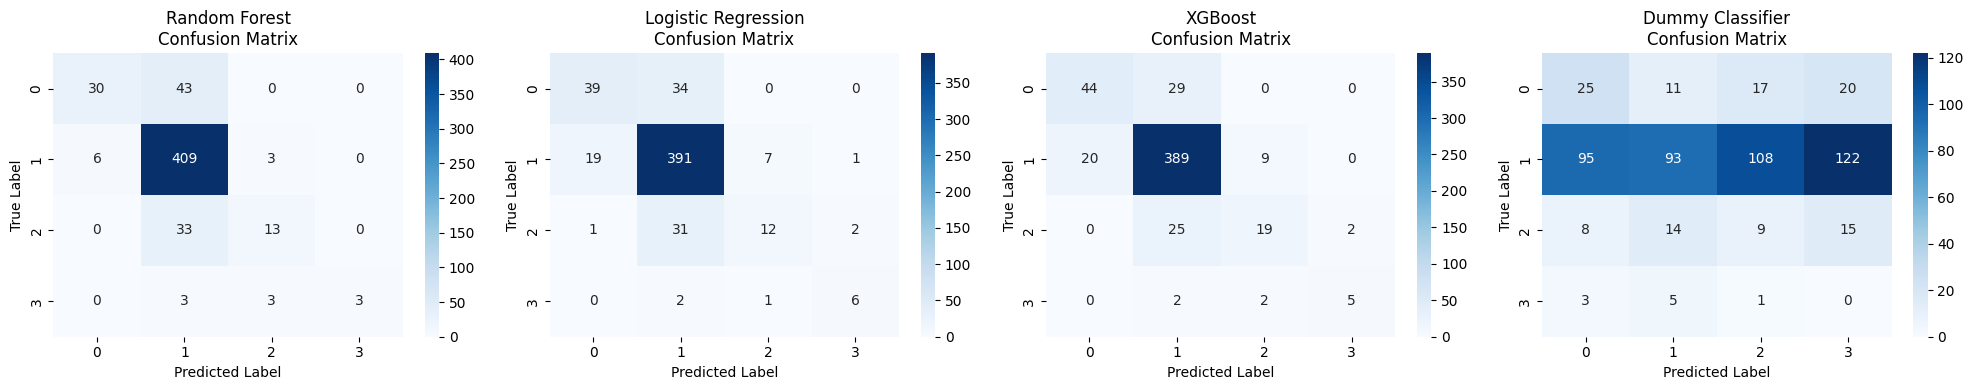

In [224]:
# Accuracy scores
acc_rf = accuracy_score(y_test, rf_preds)
acc_lr = accuracy_score(y_test, lr_preds)
acc_xgb = accuracy_score(y_test, xgb_preds)
acc_ens = accuracy_score(y_test, ensemble_preds)


accuracy_data = {
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost', 'Dummy Classifier'],
    'Accuracy': [acc_rf, acc_lr, acc_xgb, acc_dummy]
}

# accuracy_data['Model'].append('Ensemble')
# accuracy_data['Accuracy'].append(acc_ens)

acc_df = pd.DataFrame(accuracy_data)

# Bar chart of accuracies
plt.figure(figsize=(6, 4))
sns.barplot(data=acc_df, x='Model', y='Accuracy', palette='Blues_d')
plt.ylim(0, 1)
plt.title('Accuracy Comparison')
for index, row in acc_df.iterrows():
    plt.text(
        index, 
        row['Accuracy'] + 0.01, 
        f"{row['Accuracy']:.3f}",
        ha='center', 
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

# Plot confusion matrices for each model
models = ['Random Forest', 'Logistic Regression', 'XGBoost', 'Dummy Classifier']
predictions = [rf_preds, lr_preds, xgb_preds, dummy_preds]

# models.append('Ensemble')
# predictions.append(ensemble_preds)

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

for i, (model, preds) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{model}\nConfusion Matrix")
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()


# Ablation Testing

##  Remove review feature group to assess impact


In [212]:
## 1. Ablating Review Scores

# Define the review score columns to ablate
review_score_cols = [
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
# Drop review score columns
X_ablation = X.drop(columns=review_score_cols, errors='ignore')

# Split Data
X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
    X_ablation, y, test_size=0.2, stratify=y, random_state=42
)

# Refit the preprocessor on the new data
numeric_features = X_ablation.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_ablation.select_dtypes(include=['object']).columns.tolist()

# Column transformer for imputing and encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Transform the ablated dataset
X_train_ab_processed = preprocessor.fit_transform(X_train_ab)
X_test_ab_processed = preprocessor.transform(X_test_ab)

# Apply SMOTE again
X_train_ab_resampled, y_train_ab_resampled = smote.fit_resample(X_train_ab_processed, y_train_ab)


In [213]:
## 2. # Train and evaluate models without review scores

## Random Forest
rf_pipeline_ab = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_pipeline_ab.fit(X_train_ab, y_train_ab)
rf_preds_ab = rf_pipeline_ab.predict(X_test_ab)

acc_rf_ab = accuracy_score(y_test_ab, rf_preds_ab)
precision_rf_ab = precision_score(y_test_ab, rf_preds_ab, average='macro')
f1_rf_ab = f1_score(y_test_ab, rf_preds_ab, average='macro')

## Logistic Regression
lr_pipeline_ab = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(random_state=42))
])

lr_pipeline_ab.fit(X_train_ab, y_train_ab)
lr_preds_ab = lr_pipeline_ab.predict(X_test_ab)

acc_lr_ab = accuracy_score(y_test_ab, lr_preds_ab)
precision_lr_ab = precision_score(y_test_ab, lr_preds_ab, average='macro')
f1_lr_ab = f1_score(y_test_ab, lr_preds_ab, average='macro')

## XGBoost
xgb_pipeline_ab = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

xgb_pipeline_ab.fit(X_train_ab, y_train_ab)
xgb_preds_ab = xgb_pipeline_ab.predict(X_test_ab)

acc_xgb_ab = accuracy_score(y_test_ab, xgb_preds_ab)
precision_xgb_ab = precision_score(y_test_ab, xgb_preds_ab, average='macro')
f1_xgb_ab = f1_score(y_test_ab, xgb_preds_ab, average='macro')

# Compare results with full-feature models
all_scores_ablation = {
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Full Model Accuracy': [acc_rf, acc_lr, acc_xgb],
    'Ablation Accuracy': [acc_rf_ab, acc_lr_ab, acc_xgb_ab],
    'Full Model Precision': [precision_rf, precision_lr, precision_xgb],
    'Ablation Precision': [precision_rf_ab, precision_lr_ab, precision_xgb_ab],
    'Full Model F1': [f1_rf, f1_lr, f1_xgb],
    'Ablation F1': [f1_rf_ab, f1_lr_ab, f1_xgb_ab]

}

all_scores_ab_df = pd.DataFrame(all_scores_ablation)
all_scores_ab_df

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Full Model Accuracy,Ablation Accuracy,Full Model Precision,Ablation Precision,Full Model F1,Ablation F1
0,Random Forest,0.833333,0.829670,0.838915,0.762655,0.588332,0.621239
1,Logistic Regression,0.820513,0.826007,0.695349,0.743936,0.628477,0.658935
2,XGBoost,0.836996,0.846154,0.727319,0.713963,0.667211,0.668233


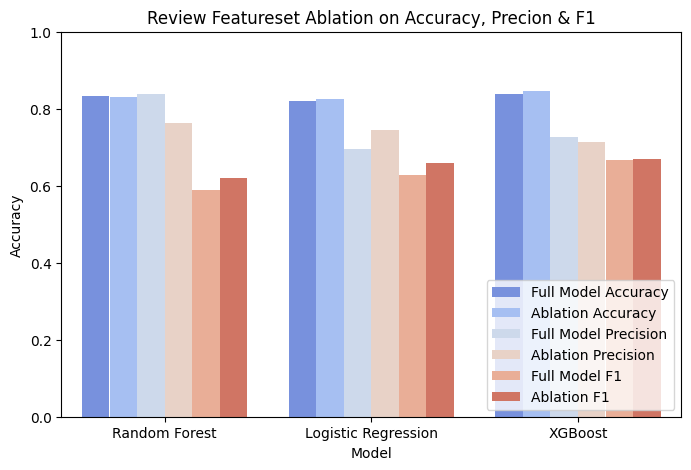

In [214]:
# Plot the accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=pd.melt(all_scores_ab_df, id_vars=['Model'], var_name='Condition', value_name='Accuracy'),
            x='Model', y='Accuracy', hue='Condition', palette='coolwarm')
plt.ylim(0, 1)
plt.title('Review Featureset Ablation on Accuracy, Precion & F1')
plt.legend(loc='lower right')
plt.show()

# Remove property features to assess impact

In [215]:
# Drop property detail related columns
X_neighborhood_dropped = X.drop(columns=['neighbourhood','property_type', 'room_type', 'accommodates',
       'bathrooms', 'bathrooms_text', 'bedrooms', 'beds'], errors='ignore')

# Split the data
X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_neighborhood_dropped, y, test_size=0.2, stratify=y, random_state=42
)

# Refit the preprocessor on the new data (after dropping 'neighbourhood_cleansed')
numeric_features = X_neighborhood_dropped.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_neighborhood_dropped.select_dtypes(include=['object']).columns.tolist()

# Column transformer for imputing and encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Now, transform the data
X_train_nd_processed = preprocessor.fit_transform(X_train_nd)
X_test_nd_processed = preprocessor.transform(X_test_nd)

# Apply SMOTE again
X_train_nd_resampled, y_train_nd_resampled = smote.fit_resample(X_train_nd_processed, y_train_nd)


In [216]:
## 2. # Train and evaluate models without neighborhood scores

## Random Forest
rf_pipeline_nd = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_pipeline_nd.fit(X_train_nd, y_train_nd)
rf_preds_nd = rf_pipeline_nd.predict(X_test_nd)
acc_rf_nd = accuracy_score(y_test_nd, rf_preds_nd)
precision_rf_nd = precision_score(y_test_nd, rf_preds_nd, average='macro')
f1_rf_nd = f1_score(y_test_nd, rf_preds_nd, average='macro')

## Logistic Regression
lr_pipeline_nd = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(random_state=42))
])

lr_pipeline_nd.fit(X_train_nd, y_train_nd)
lr_preds_nd = lr_pipeline_nd.predict(X_test_nd)
acc_lr_nd = accuracy_score(y_test_nd, lr_preds_nd)
precision_lr_nd = precision_score(y_test_nd, lr_preds_nd, average='macro')
f1_lr_nd = f1_score(y_test_nd, lr_preds_nd, average='macro')

## XGBoost
xgb_pipeline_nd = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

xgb_pipeline_nd.fit(X_train_nd, y_train_nd)
xgb_preds_nd = xgb_pipeline_nd.predict(X_test_nd)
acc_xgb_nd = accuracy_score(y_test_nd, xgb_preds_nd)
precision_xgb_nd = precision_score(y_test_nd, xgb_preds_nd, average='macro')
f1_xgb_nd = f1_score(y_test_nd, xgb_preds_nd, average='macro')

# Compare results with full-feature models
all_scores_nd_ablation = {
    'Model': ['Random Forest', 'Logistic Regression', 'XGBoost'],
    'Full Model Accuracy': [acc_rf, acc_lr, acc_xgb],
    'Ablation Accuracy': [acc_rf_nd, acc_lr_nd, acc_xgb_nd],
    'Full Model Precision': [precision_rf, precision_lr, precision_xgb],
    'Ablation Precision': [precision_rf_nd, precision_lr_nd, precision_xgb_nd],
    'Full Model F1': [f1_rf, f1_lr, f1_xgb],
    'Ablation F1': [f1_rf_nd, f1_lr_nd, f1_xgb_nd]

}

all_scores_nd_df = pd.DataFrame(all_scores_nd_ablation)
all_scores_nd_df

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Full Model Accuracy,Ablation Accuracy,Full Model Precision,Ablation Precision,Full Model F1,Ablation F1
0,Random Forest,0.833333,0.796703,0.838915,0.814837,0.588332,0.495436
1,Logistic Regression,0.820513,0.754579,0.695349,0.493750,0.628477,0.340923
2,XGBoost,0.836996,0.780220,0.727319,0.654152,0.667211,0.510790


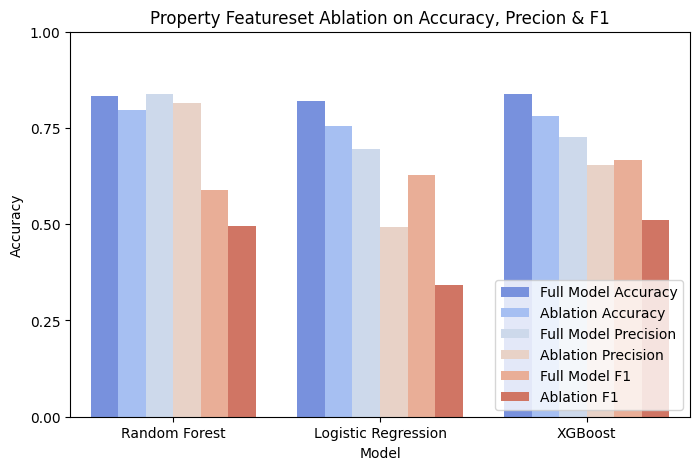

In [217]:
# Plot the accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=pd.melt(all_scores_nd_df, id_vars=['Model'], var_name='Condition', value_name='Accuracy'),
            x='Model', y='Accuracy', hue='Condition', palette='coolwarm')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.25, 0.25))  # Set ticks from 0 to 1 with a step of 0.25
plt.title('Property Featureset Ablation on Accuracy, Precion & F1')
plt.legend(loc='lower right')
plt.show()